# WSI Embedding — Analyse de l'espace latent

Ce notebook analyse les embeddings de Whole Slide Images (WSI) chargés depuis des fichiers `.h5`.

**Pipeline :**
1. Chargement des embeddings et des labels
2. Statistiques descriptives
3. PCA — variance expliquée, projection 2D/3D, biplots
4. UMAP — projection non-linéaire
5. t-SNE — projection non-linéaire alternative
6. Analyse de séparabilité (silhouette, distances inter/intra-classe)
7. Clustering non supervisé (KMeans) et comparaison aux labels
8. Heatmap de corrélation des dimensions principales

In [68]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score,
    normalized_mutual_info_score, confusion_matrix
)
from scipy.spatial.distance import cdist

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("⚠️  umap-learn non installé — UMAP sera ignoré. Installez avec : pip install umap-learn")

try:
    import plotly.express as px
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("⚠️  plotly non installé — les graphiques 3D interactifs seront ignorés.")

# Style global
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = {0: '#4C72B0', 1: '#DD8452'}  # Bleu / Orange
LABEL_NAMES = {0: 'Négatif (0)', 1: 'Positif (1)'}

print("✅ Imports OK")

✅ Imports OK


In [69]:
## directions
H5_DIR   = "D:/Embeddings/Data_CHU/UNI2H_embeddings/IHC/"       
CSV_PATH = "C:/Users/manon/Documents/pathology_MIL/data/splits_chu/data_chu_split.csv"       
H5_KEY   = "embeddings"            
                                 
OUTPUT_DIR = "./figures"         
RANDOM_STATE = 42
# ───────────────────────────────────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Figures sauvegardées dans : {OUTPUT_DIR}")

Figures sauvegardées dans : ./figures


## 1. Chargement des données

In [70]:
def load_h5_embedding(path: str, key: str = None) -> np.ndarray:
    """Charge un embedding depuis un fichier h5.
    Si key=None, prend le premier dataset disponible.
    Si l'embedding est 2D (N_patches x D), retourne la moyenne (bag-level).
    """
    with h5py.File(path, 'r') as f:
        if key is None:
            key = list(f.keys())[0]
        data = f[key][()]  # charge en mémoire
    # Gestion des différentes formes possibles
    if data.ndim == 1:
        return data.astype(np.float32)
    elif data.ndim == 2:
        # N_patches x D → agrégation par moyenne (MIL bag-level)
        return data.mean(axis=0).astype(np.float32)
    else:
        raise ValueError(f"Forme inattendue : {data.shape} dans {path}")


# Chargement du CSV
df_labels = pd.read_csv(CSV_PATH)
df_labels['id'] = df_labels['slide_id'].astype(str)
print(f"CSV chargé : {len(df_labels)} entrées | Distribution : {df_labels['label'].value_counts().to_dict()}")

# Chargement des embeddings
embeddings, ids, labels = [], [], []
missing = []

for _, row in tqdm(df_labels.iterrows(), total=len(df_labels), desc="Chargement h5"):
    wsi_id = str(row['id'])
    h5_path = os.path.join(H5_DIR, f"{wsi_id}.h5")
    if not os.path.exists(h5_path):
        missing.append(wsi_id)
        continue
    try:
        emb = load_h5_embedding(h5_path, key=H5_KEY if H5_KEY else None)
        embeddings.append(emb)
        ids.append(wsi_id)
        labels.append(int(row['label']))
    except Exception as e:
        print(f"  ⚠️  Erreur sur {wsi_id}: {e}")

if missing:
    print(f"\n⚠️  {len(missing)} fichiers h5 introuvables : {missing[:5]}{'...' if len(missing)>5 else ''}")

X = np.stack(embeddings)          # (N, D)
y = np.array(labels)              # (N,)

print(f"\n✅ Embeddings chargés : {X.shape[0]} WSI | Dimension : {X.shape[1]}")
print(f"   Labels — 0: {(y==0).sum()} | 1: {(y==1).sum()}")

CSV chargé : 110 entrées | Distribution : {1: 89, 0: 21}


Chargement h5:   0%|          | 0/110 [00:00<?, ?it/s]

Chargement h5:  19%|█▉        | 21/110 [00:07<00:32,  2.73it/s]

  ⚠️  Erreur sur 25P15592: Unable to synchronously open file (bad object header version number)


Chargement h5: 100%|██████████| 110/110 [00:34<00:00,  3.18it/s]


⚠️  14 fichiers h5 introuvables : ['26P45463', '26P450', '26P699', '26P55', '26P767']...

✅ Embeddings chargés : 95 WSI | Dimension : 1536
   Labels — 0: 17 | 1: 78


## 2. Statistiques descriptives

  Nombre de WSI       : 95
  Dimension embedding : 1536
  Label 0 (négatif)   : 17 (17.9%)
  Label 1 (positif)   : 78 (82.1%)
───────────────────────────────────────────────────────
  Valeur min / max    : -1.6137 / 1.7776
  Moyenne globale     : 0.0023
  Écart-type global   : 0.2876
  % valeurs nulles    : 0.00%


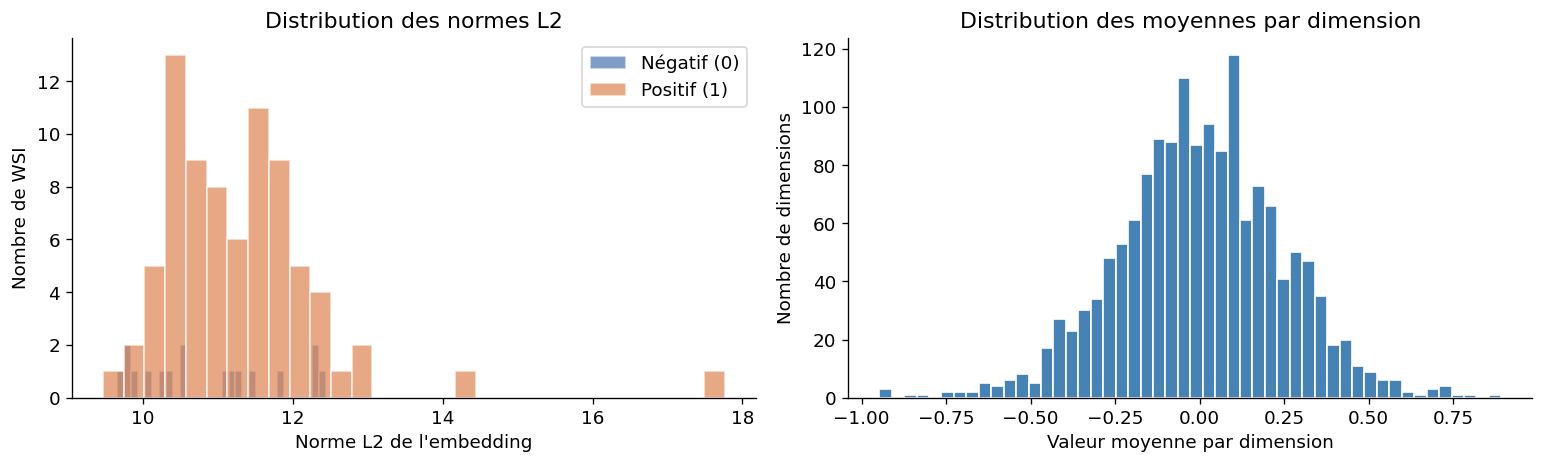

In [71]:
print("=" * 55)
print(f"  Nombre de WSI       : {X.shape[0]}")
print(f"  Dimension embedding : {X.shape[1]}")
print(f"  Label 0 (négatif)   : {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"  Label 1 (positif)   : {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")
print("─" * 55)
print(f"  Valeur min / max    : {X.min():.4f} / {X.max():.4f}")
print(f"  Moyenne globale     : {X.mean():.4f}")
print(f"  Écart-type global   : {X.std():.4f}")
print(f"  % valeurs nulles    : {(X == 0).mean()*100:.2f}%")
print("=" * 55)

# Distribution des normes L2
norms = np.linalg.norm(X, axis=1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label_val, color in PALETTE.items():
    mask = y == label_val
    axes[0].hist(norms[mask], bins=30, alpha=0.7, color=color, label=LABEL_NAMES[label_val], edgecolor='white')
axes[0].set_xlabel('Norme L2 de l\'embedding')
axes[0].set_ylabel('Nombre de WSI')
axes[0].set_title('Distribution des normes L2')
axes[0].legend()

# Distribution de la moyenne par dimension
axes[1].hist(X.mean(axis=0), bins=50, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Valeur moyenne par dimension')
axes[1].set_ylabel('Nombre de dimensions')
axes[1].set_title('Distribution des moyennes par dimension')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '00_stats_descriptives.png'), bbox_inches='tight')
plt.show()

## 3. Normalisation

In [72]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"✅ Normalisation StandardScaler appliquée (μ≈0, σ≈1 par dimension)")

✅ Normalisation StandardScaler appliquée (μ≈0, σ≈1 par dimension)


## 4. PCA

Composantes pour 90% de variance : 24
Composantes pour 95% de variance : 36
Composantes pour 99% de variance : 64


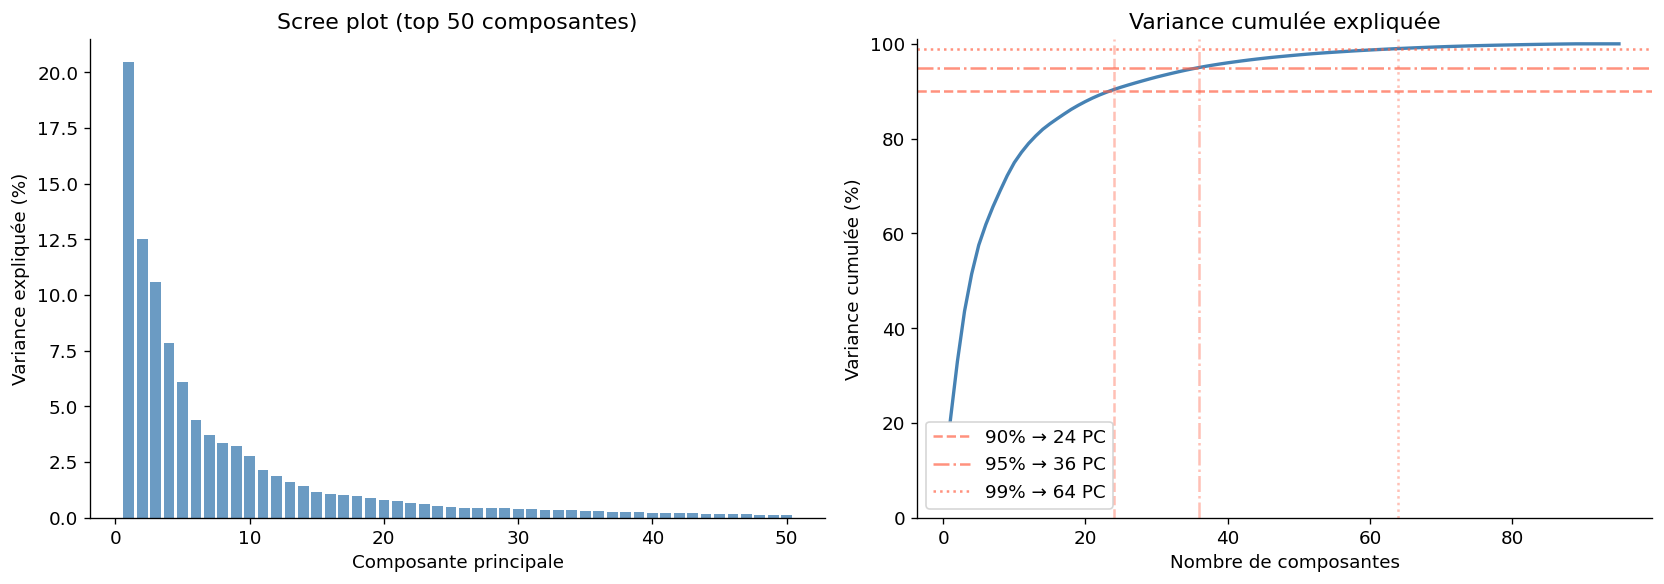

In [73]:
# ── 4.1 Variance expliquée ────────────────────────────────────────────────
n_components_full = min(X_scaled.shape[0], X_scaled.shape[1])
pca_full = PCA(n_components=n_components_full, random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

n_90 = np.searchsorted(cumulative, 0.90) + 1
n_95 = np.searchsorted(cumulative, 0.95) + 1
n_99 = np.searchsorted(cumulative, 0.99) + 1

print(f"Composantes pour 90% de variance : {n_90}")
print(f"Composantes pour 95% de variance : {n_95}")
print(f"Composantes pour 99% de variance : {n_99}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot (individuelle)
n_show = min(50, len(explained))
axes[0].bar(range(1, n_show + 1), explained[:n_show] * 100, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Composante principale')
axes[0].set_ylabel('Variance expliquée (%)')
axes[0].set_title(f'Scree plot (top {n_show} composantes)')

# Variance cumulée
n_plot = min(200, len(cumulative))
axes[1].plot(range(1, n_plot + 1), cumulative[:n_plot] * 100, color='steelblue', linewidth=2)
for thresh, n, ls in [(90, n_90, '--'), (95, n_95, '-.'), (99, n_99, ':')]:
    axes[1].axhline(thresh, color='tomato', linestyle=ls, alpha=0.7, label=f'{thresh}% → {n} PC')
    axes[1].axvline(n, color='tomato', linestyle=ls, alpha=0.4)
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulée (%)')
axes[1].set_title('Variance cumulée expliquée')
axes[1].legend()
axes[1].set_ylim([0, 101])

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '01_pca_variance.png'), bbox_inches='tight')
plt.show()

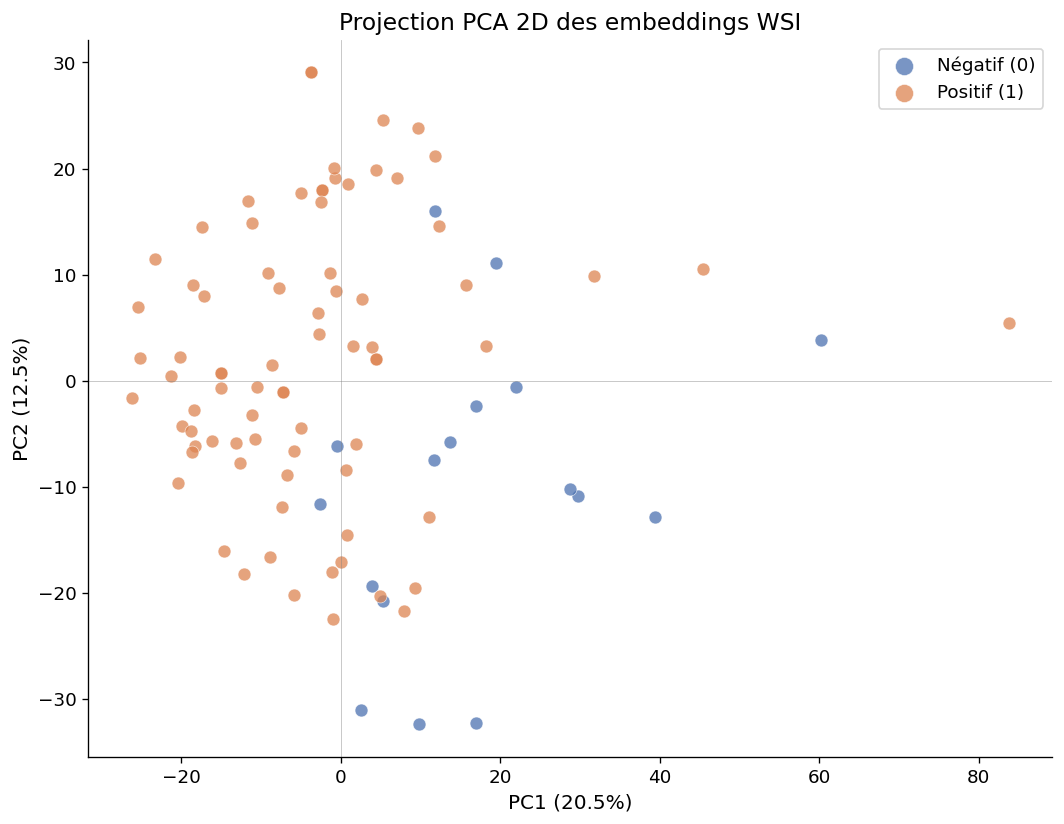

In [74]:
# ── 4.2 Projection 2D colorée par label ──────────────────────────────────
pca_2d = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca2 = pca_2d.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
for label_val, color in PALETTE.items():
    mask = y == label_val
    ax.scatter(
        X_pca2[mask, 0], X_pca2[mask, 1],
        c=color, label=LABEL_NAMES[label_val],
        alpha=0.75, s=60, edgecolors='white', linewidths=0.4
    )

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('Projection PCA 2D des embeddings WSI', fontsize=14)
ax.legend(fontsize=11, markerscale=1.4)
ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '02_pca_2d.png'), bbox_inches='tight')
plt.show()

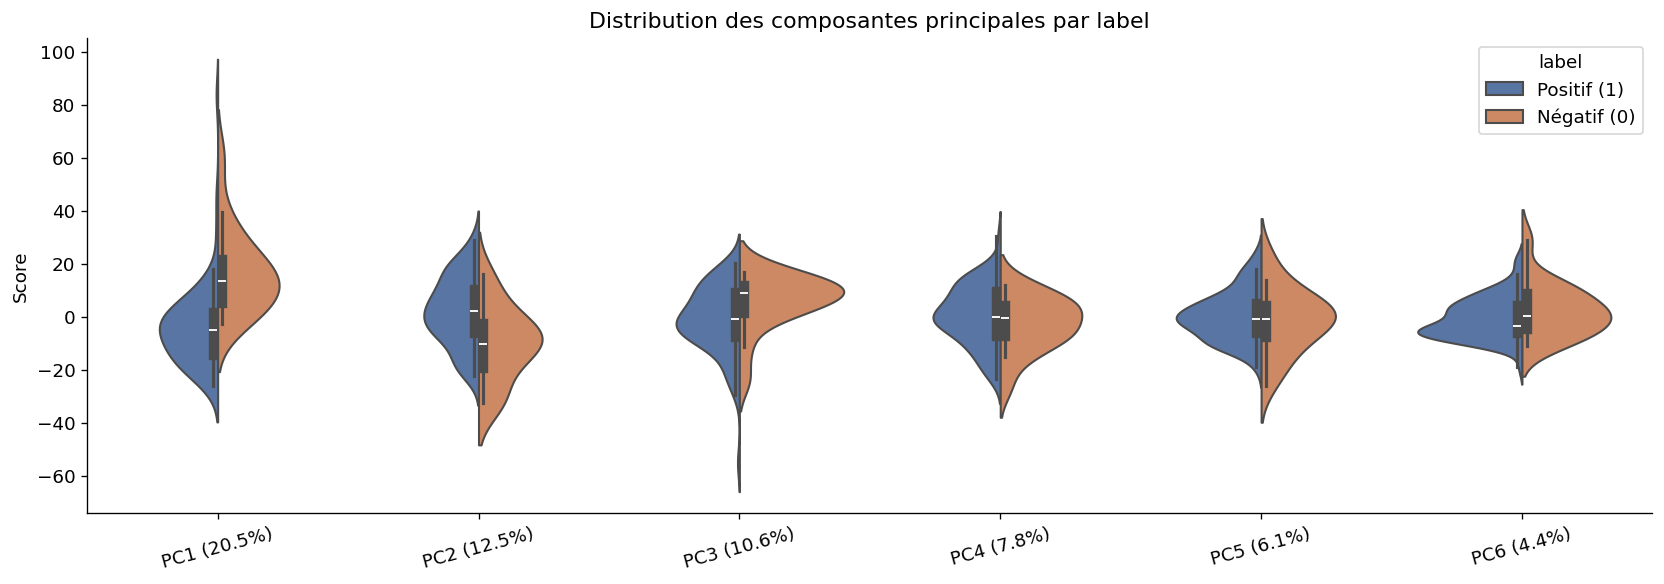

In [75]:
# ── 4.4 Distribution des PC1–PC6 par label (violins) ────────────────────
n_pc_show = min(6, n_components_full)
pca_n = PCA(n_components=n_pc_show, random_state=RANDOM_STATE)
X_pca_n = pca_n.fit_transform(X_scaled)

df_pca = pd.DataFrame(
    X_pca_n,
    columns=[f'PC{i+1} ({pca_n.explained_variance_ratio_[i]*100:.1f}%)' for i in range(n_pc_show)]
)
df_pca['label'] = [LABEL_NAMES[v] for v in y]
df_pca_long = df_pca.melt(id_vars='label', var_name='Composante', value_name='Score')

fig, ax = plt.subplots(figsize=(14, 5))
sns.violinplot(
    data=df_pca_long, x='Composante', y='Score', hue='label',
    palette=list(PALETTE.values()), split=True, inner='box', ax=ax
)
ax.set_title('Distribution des composantes principales par label')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '03_pca_distributions.png'), bbox_inches='tight')
plt.show()

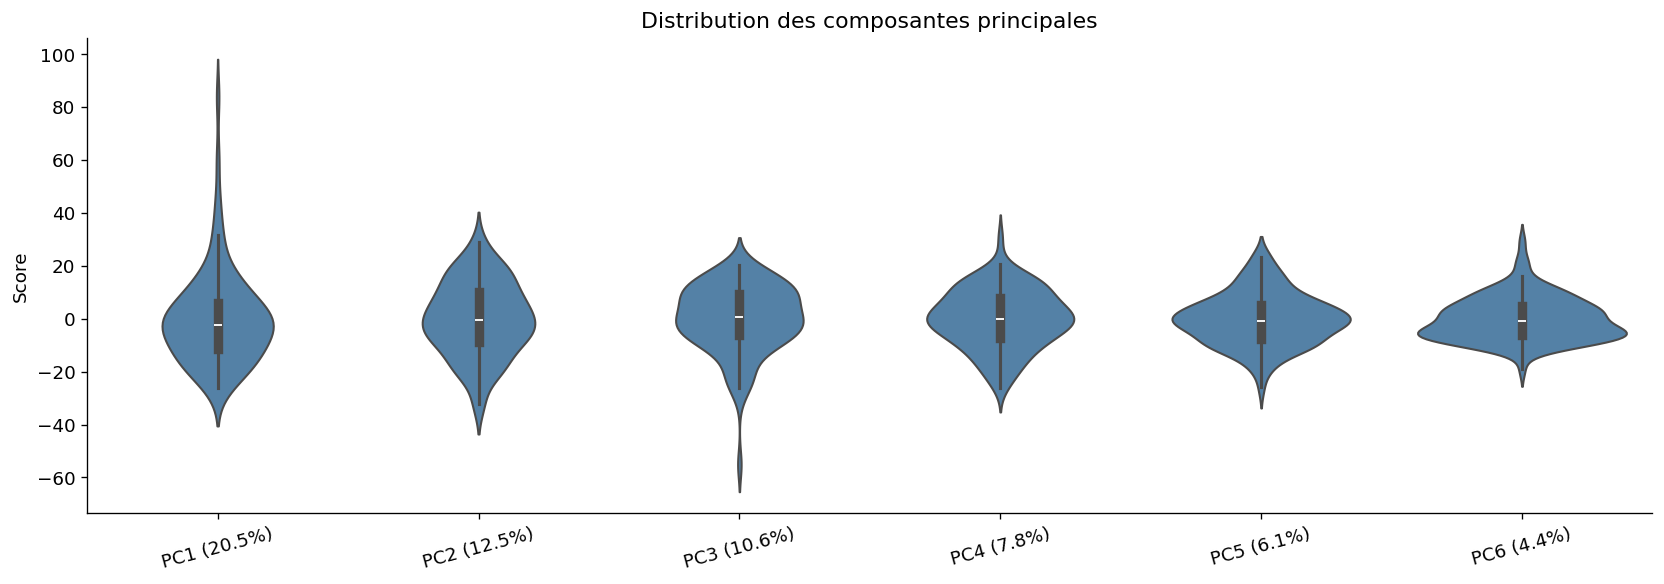

In [76]:
# ── 4.4 Distribution des PC1–PC6 (violins, tous individus) ──────────────
n_pc_show = min(6, n_components_full)
pca_n = PCA(n_components=n_pc_show, random_state=RANDOM_STATE)
X_pca_n = pca_n.fit_transform(X_scaled)

df_pca = pd.DataFrame(
    X_pca_n,
    columns=[f'PC{i+1} ({pca_n.explained_variance_ratio_[i]*100:.1f}%)' for i in range(n_pc_show)]
)
df_pca_long = df_pca.melt(var_name='Composante', value_name='Score')

fig, ax = plt.subplots(figsize=(14, 5))
sns.violinplot(
    data=df_pca_long, x='Composante', y='Score',
    color='steelblue', inner='box', ax=ax
)
ax.set_title('Distribution des composantes principales')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '03_pca_distributions.png'), bbox_inches='tight')
plt.show()

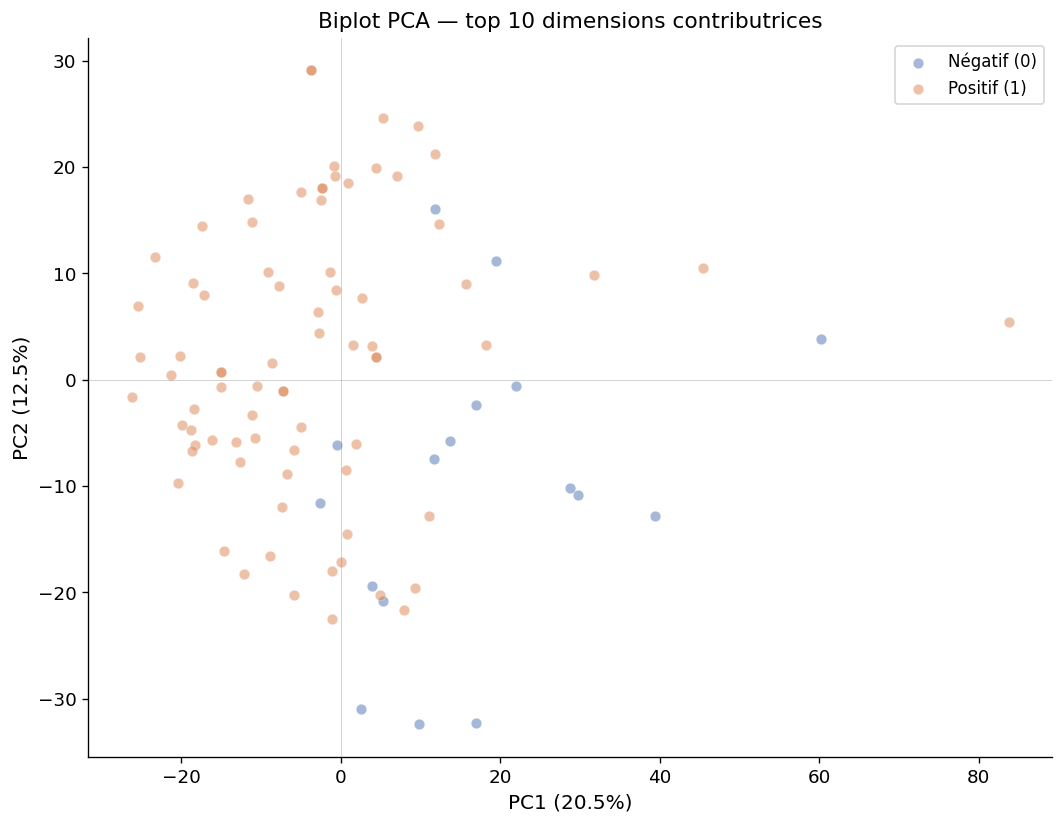

In [77]:
# ── 4.5 Biplot PC1/PC2 (top contributing features) ───────────────────────
n_arrows = 10  # Nombre de dimensions les plus contributrices à afficher
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2_scores = pca2.fit_transform(X_scaled)

loadings = pca2.components_.T  # (D, 2)
loading_norms = np.linalg.norm(loadings, axis=1)
top_idx = np.argsort(loading_norms)[-n_arrows:]

# Facteur d'échelle pour les flèches
scale = np.abs(X_pca2_scores).max() / np.abs(loadings[top_idx]).max() * 0.6

fig, ax = plt.subplots(figsize=(9, 7))
for label_val, color in PALETTE.items():
    mask = y == label_val
    ax.scatter(
        X_pca2_scores[mask, 0], X_pca2_scores[mask, 1],
        c=color, label=LABEL_NAMES[label_val],
        alpha=0.5, s=40, edgecolors='white', linewidths=0.3
    )

for i in top_idx:
    ax.annotate(
        f'dim {i}',
        xy=(loadings[i, 0] * scale, loadings[i, 1] * scale),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='black', lw=1.0),
        fontsize=8, color='black', ha='center'
    )

ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title(f'Biplot PCA — top {n_arrows} dimensions contributrices', fontsize=13)
ax.legend(fontsize=10)
ax.axhline(0, color='gray', lw=0.5, alpha=0.4)
ax.axvline(0, color='gray', lw=0.5, alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '04_pca_biplot.png'), bbox_inches='tight')
plt.show()

## 5. UMAP

Calcul UMAP (peut prendre quelques secondes)...
✅ UMAP terminé


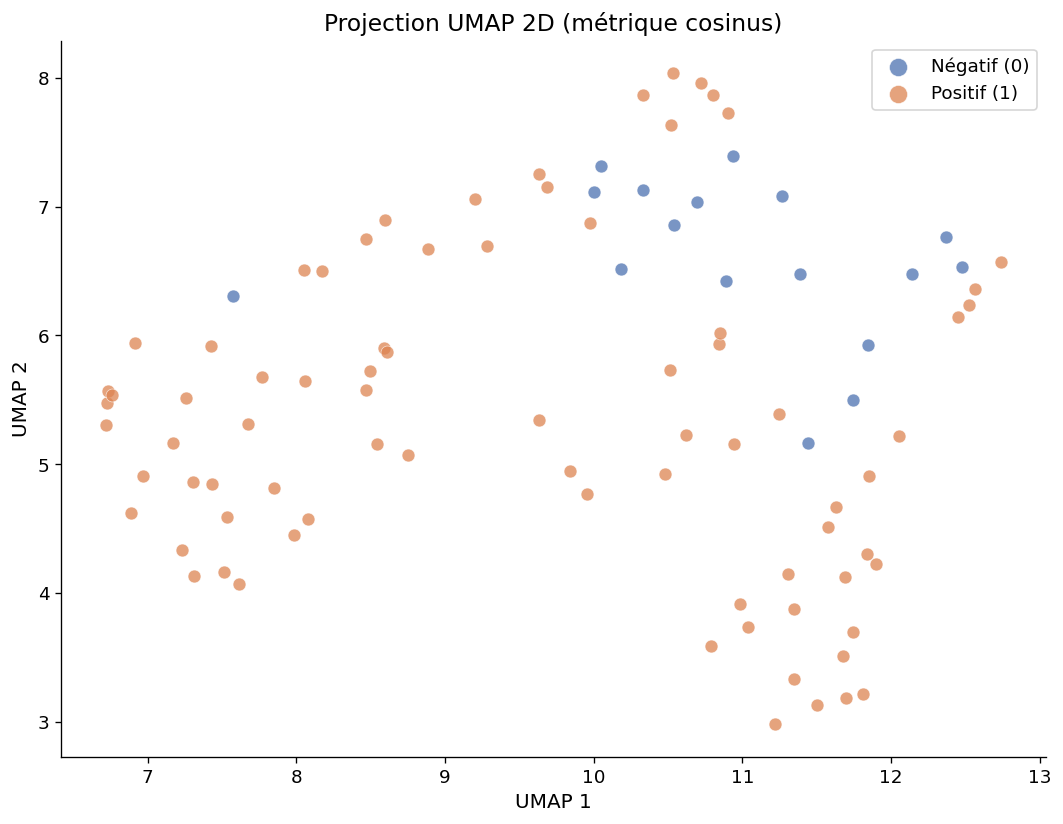

In [78]:
if UMAP_AVAILABLE:
    print("Calcul UMAP (peut prendre quelques secondes)...")
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        n_components=2,
        metric='cosine',
        random_state=RANDOM_STATE
    )
    X_umap = reducer.fit_transform(X_scaled)
    print("✅ UMAP terminé")

    fig, ax = plt.subplots(figsize=(9, 7))
    for label_val, color in PALETTE.items():
        mask = y == label_val
        ax.scatter(
            X_umap[mask, 0], X_umap[mask, 1],
            c=color, label=LABEL_NAMES[label_val],
            alpha=0.75, s=60, edgecolors='white', linewidths=0.4
        )
    ax.set_xlabel('UMAP 1', fontsize=12)
    ax.set_ylabel('UMAP 2', fontsize=12)
    ax.set_title('Projection UMAP 2D (métrique cosinus)', fontsize=14)
    ax.legend(fontsize=11, markerscale=1.4)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, '06_umap_2d.png'), bbox_inches='tight')
    plt.show()
else:
    print("UMAP non disponible.")

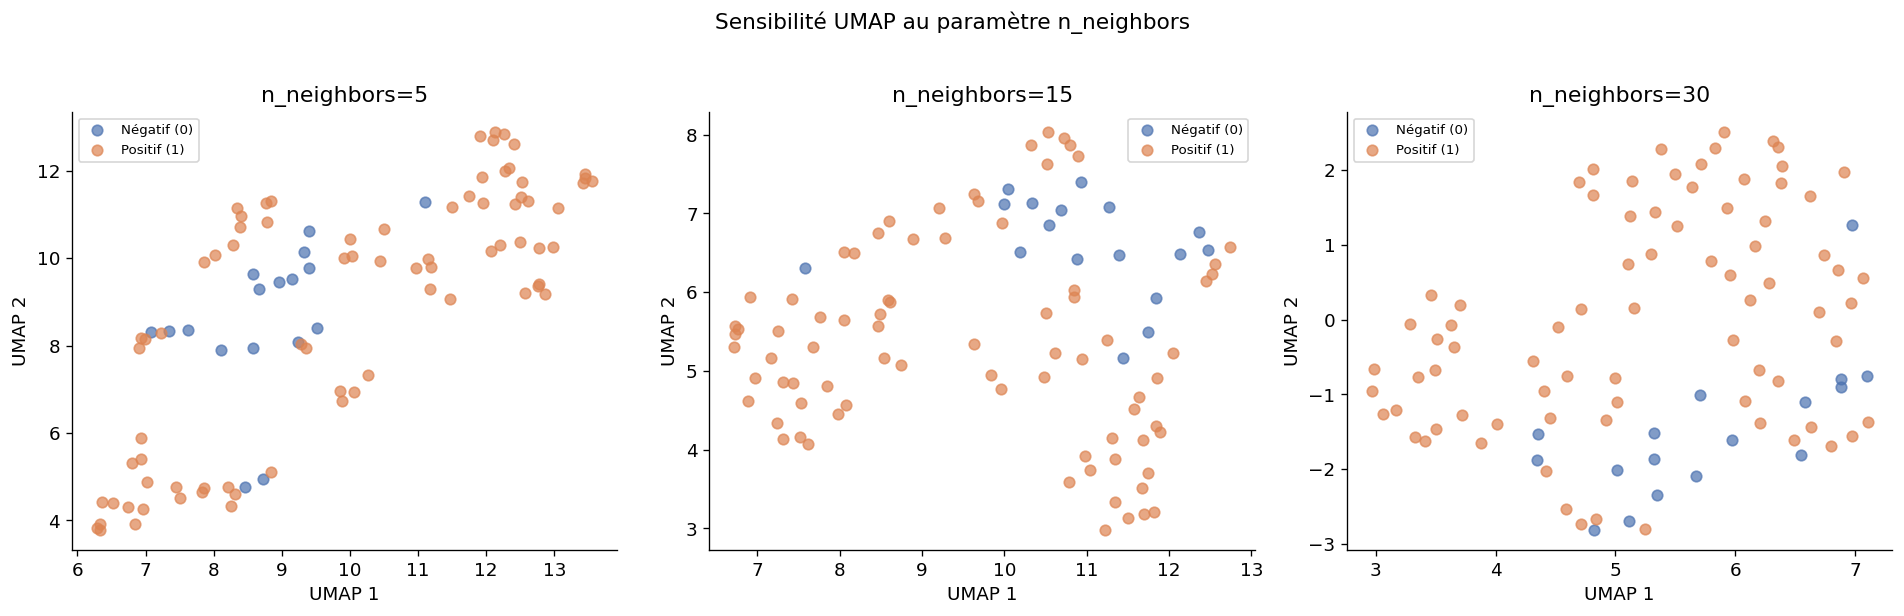

In [79]:
# Sensibilité UMAP — effet des hyperparamètres
if UMAP_AVAILABLE:
    neighbors_list = [5, 15, 30]
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for ax, n_neighbors in zip(axes, neighbors_list):
        r = umap.UMAP(n_neighbors=n_neighbors, min_dist=0.1, metric='cosine', random_state=RANDOM_STATE)
        X_u = r.fit_transform(X_scaled)
        for label_val, color in PALETTE.items():
            mask = y == label_val
            ax.scatter(X_u[mask, 0], X_u[mask, 1], c=color,
                       label=LABEL_NAMES[label_val], alpha=0.7, s=40)
        ax.set_title(f'n_neighbors={n_neighbors}')
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
        ax.legend(fontsize=8)

    plt.suptitle('Sensibilité UMAP au paramètre n_neighbors', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, '07_umap_sensitivity.png'), bbox_inches='tight')
    plt.show()

## 6. t-SNE

Calcul t-SNE (peut prendre 1-2 minutes sur grands datasets)...
✅ t-SNE terminé | KL divergence finale : 0.3696


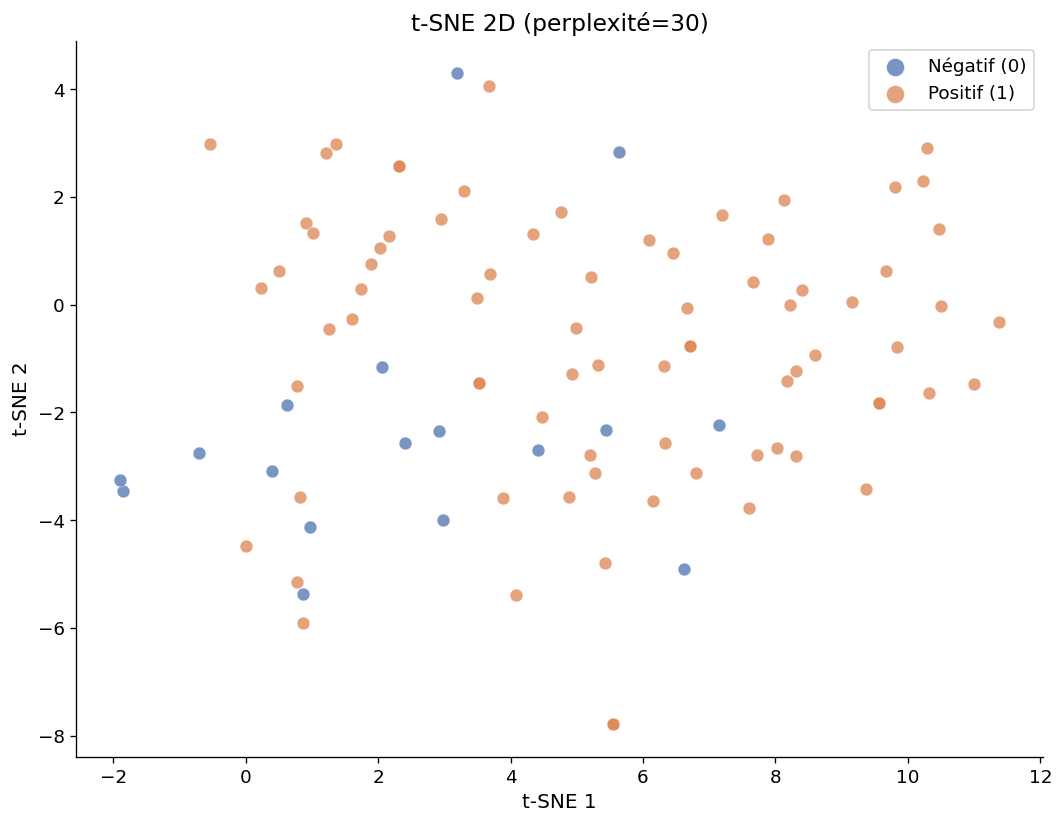

In [80]:
print("Calcul t-SNE (peut prendre 1-2 minutes sur grands datasets)...")

# Pré-réduction PCA recommandée avant t-SNE si D > 50
n_pca_tsne = min(50, X_scaled.shape[1], X_scaled.shape[0])
X_pre = PCA(n_components=n_pca_tsne, random_state=RANDOM_STATE).fit_transform(X_scaled)

tsne = TSNE(
    n_components=2,
    perplexity=min(30, X.shape[0] // 3),
    learning_rate='auto',
    init='pca',
    max_iter=1000,
    random_state=RANDOM_STATE
)
X_tsne = tsne.fit_transform(X_pre)
print(f"✅ t-SNE terminé | KL divergence finale : {tsne.kl_divergence_:.4f}")

fig, ax = plt.subplots(figsize=(9, 7))
for label_val, color in PALETTE.items():
    mask = y == label_val
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=color, label=LABEL_NAMES[label_val],
        alpha=0.75, s=60, edgecolors='white', linewidths=0.4
    )
ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title(f't-SNE 2D (perplexité={min(30, X.shape[0]//3)})', fontsize=14)
ax.legend(fontsize=11, markerscale=1.4)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '08_tsne_2d.png'), bbox_inches='tight')
plt.show()

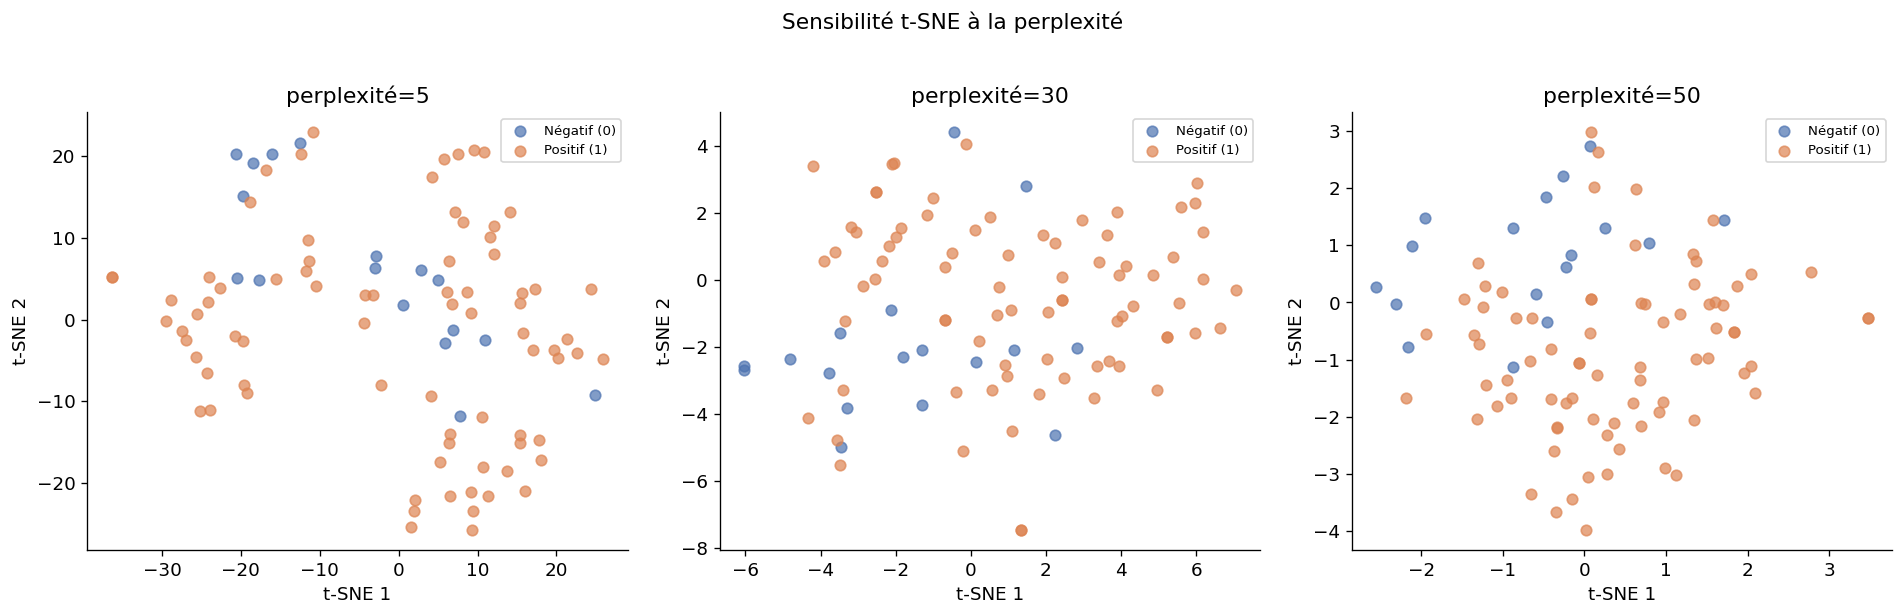

In [81]:
# Sensibilité t-SNE à la perplexité
perplexities = [5, 30, 50]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, perp in zip(axes, perplexities):
    if perp >= X.shape[0]:
        ax.text(0.5, 0.5, f'perplexité {perp}\n> N échantillons', ha='center', va='center',
                transform=ax.transAxes)
        continue
    t = TSNE(n_components=2, perplexity=perp, init='pca',
             learning_rate='auto', max_iter=500, random_state=RANDOM_STATE)
    Xt = t.fit_transform(X_pre)
    for label_val, color in PALETTE.items():
        mask = y == label_val
        ax.scatter(Xt[mask, 0], Xt[mask, 1], c=color,
                   label=LABEL_NAMES[label_val], alpha=0.7, s=40)
    ax.set_title(f'perplexité={perp}')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(fontsize=8)

plt.suptitle('Sensibilité t-SNE à la perplexité', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '09_tsne_sensitivity.png'), bbox_inches='tight')
plt.show()

## 7. Analyse de séparabilité

  Silhouette [      Brut (normalisé)] : 0.1129
  Silhouette [           PCA (50 PC)] : 0.1169
  Silhouette [                PCA 2D] : 0.2104
  Silhouette [              t-SNE 2D] : 0.1013
  Silhouette [               UMAP 2D] : 0.0710


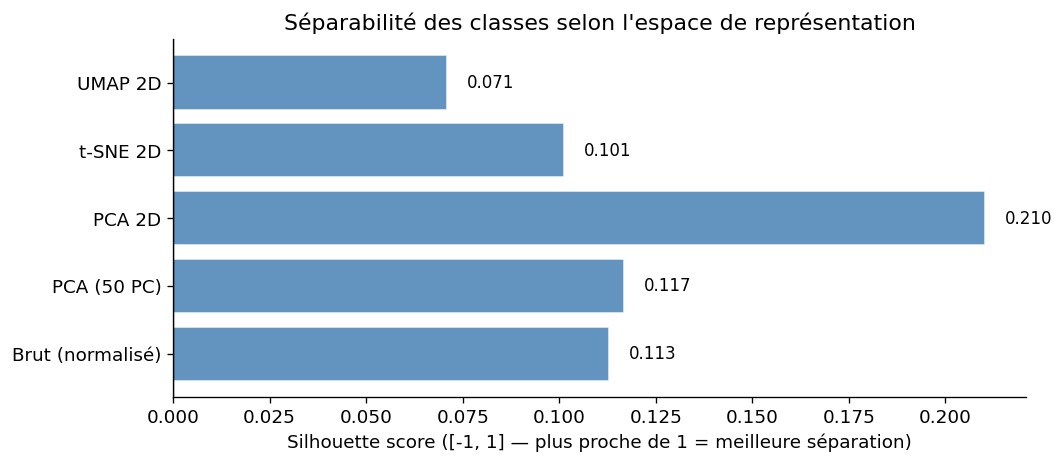

In [82]:
# ── 7.1 Silhouette score dans différents espaces ─────────────────────────
spaces = {'Brut (normalisé)': X_scaled}

n_pca_sil = min(50, X_scaled.shape[1], X_scaled.shape[0] - 1)
spaces[f'PCA ({n_pca_sil} PC)'] = PCA(n_components=n_pca_sil, random_state=RANDOM_STATE).fit_transform(X_scaled)
spaces['PCA 2D'] = X_pca2
spaces['t-SNE 2D'] = X_tsne
if UMAP_AVAILABLE:
    spaces['UMAP 2D'] = X_umap

sil_scores = {}
for name, X_space in spaces.items():
    if len(np.unique(y)) < 2:
        continue
    sil = silhouette_score(X_space, y, metric='euclidean', sample_size=min(500, len(y)))
    sil_scores[name] = sil
    print(f"  Silhouette [{name:>22s}] : {sil:.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(list(sil_scores.keys()), list(sil_scores.values()),
               color=['steelblue' if v > 0 else 'tomato' for v in sil_scores.values()],
               edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Silhouette score ([-1, 1] — plus proche de 1 = meilleure séparation)')
ax.set_title('Séparabilité des classes selon l\'espace de représentation')
for bar, val in zip(bars, sil_scores.values()):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '10_silhouette_scores.png'), bbox_inches='tight')
plt.show()

In [83]:
# ── 7.2 Distances intra/inter-classes ────────────────────────────────────
for space_name, X_space in [('PCA 2D', X_pca2), ('t-SNE 2D', X_tsne)]:
    X0 = X_space[y == 0]
    X1 = X_space[y == 1]

    intra0 = cdist(X0, X0, metric='euclidean').mean() if len(X0) > 1 else 0
    intra1 = cdist(X1, X1, metric='euclidean').mean() if len(X1) > 1 else 0
    inter  = cdist(X0, X1, metric='euclidean').mean() if len(X0) > 0 and len(X1) > 0 else 0

    print(f"[{space_name}]")
    print(f"  Distance intra-classe 0 : {intra0:.3f}")
    print(f"  Distance intra-classe 1 : {intra1:.3f}")
    print(f"  Distance inter-classes  : {inter:.3f}")
    ratio = inter / ((intra0 + intra1) / 2) if (intra0 + intra1) > 0 else float('inf')
    print(f"  Ratio inter/intra       : {ratio:.3f}  (> 1 = bonne séparation)\n")

[PCA 2D]
  Distance intra-classe 0 : 27.913
  Distance intra-classe 1 : 28.993
  Distance inter-classes  : 38.071
  Ratio inter/intra       : 1.338  (> 1 = bonne séparation)

[t-SNE 2D]
  Distance intra-classe 0 : 4.360
  Distance intra-classe 1 : 5.138
  Distance inter-classes  : 5.846
  Ratio inter/intra       : 1.231  (> 1 = bonne séparation)



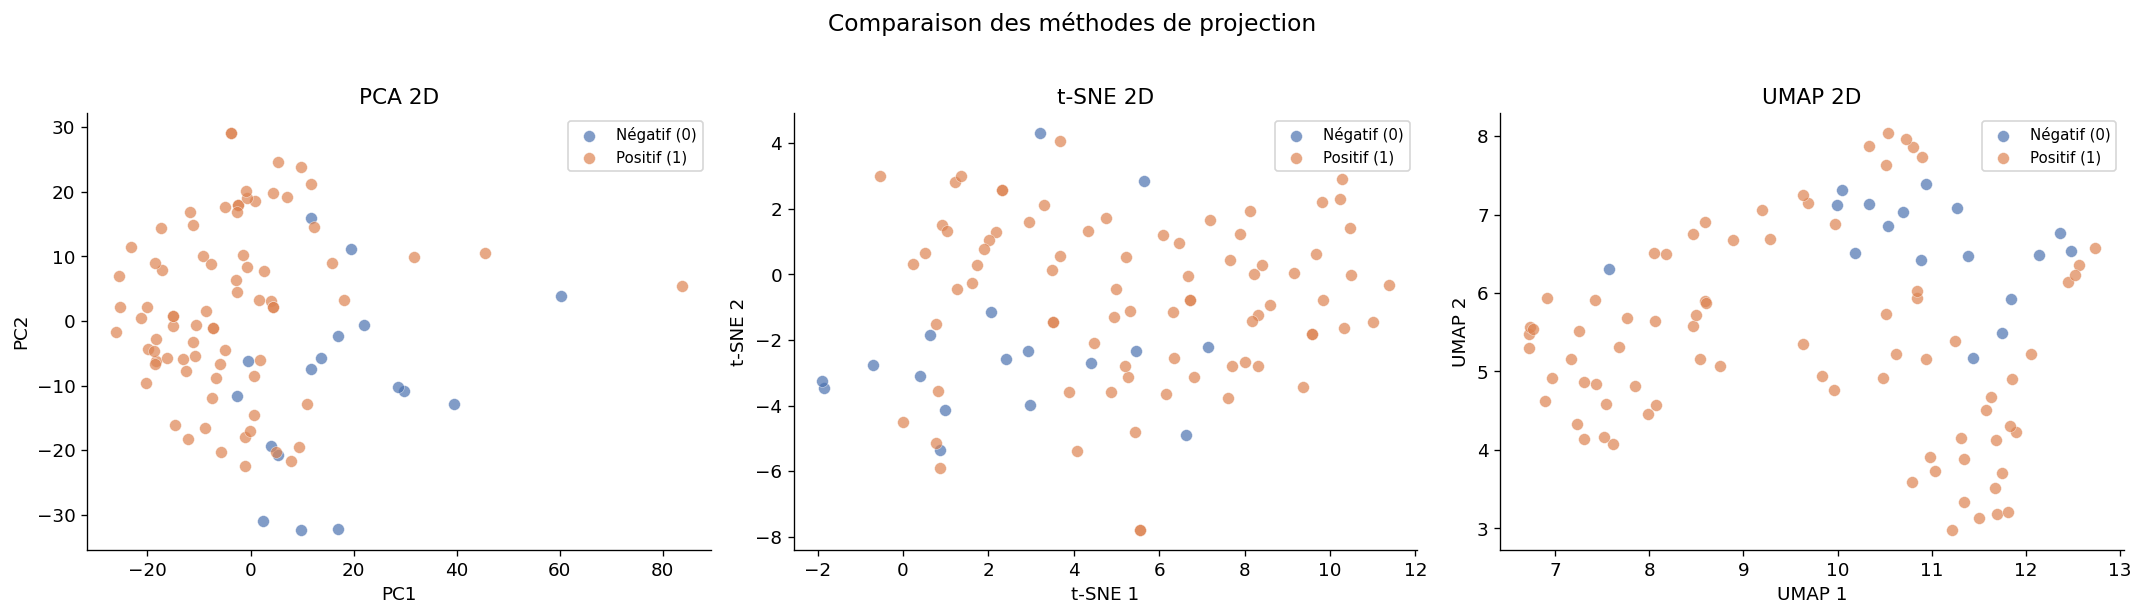

In [84]:
# ── 7.3 Comparaison côte-à-côte PCA / UMAP / t-SNE ──────────────────────
projections = [('PCA 2D', X_pca2, 'PC1', 'PC2')]
projections.append(('t-SNE 2D', X_tsne, 't-SNE 1', 't-SNE 2'))
if UMAP_AVAILABLE:
    projections.append(('UMAP 2D', X_umap, 'UMAP 1', 'UMAP 2'))

n_proj = len(projections)
fig, axes = plt.subplots(1, n_proj, figsize=(6 * n_proj, 5))
if n_proj == 1:
    axes = [axes]

for ax, (title, X_proj, xlabel, ylabel) in zip(axes, projections):
    for label_val, color in PALETTE.items():
        mask = y == label_val
        ax.scatter(X_proj[mask, 0], X_proj[mask, 1],
                   c=color, label=LABEL_NAMES[label_val],
                   alpha=0.7, s=50, edgecolors='white', linewidths=0.3)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)

plt.suptitle('Comparaison des méthodes de projection', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '11_projection_comparison.png'), bbox_inches='tight')
plt.show()

## 8. Clustering non supervisé (KMeans)

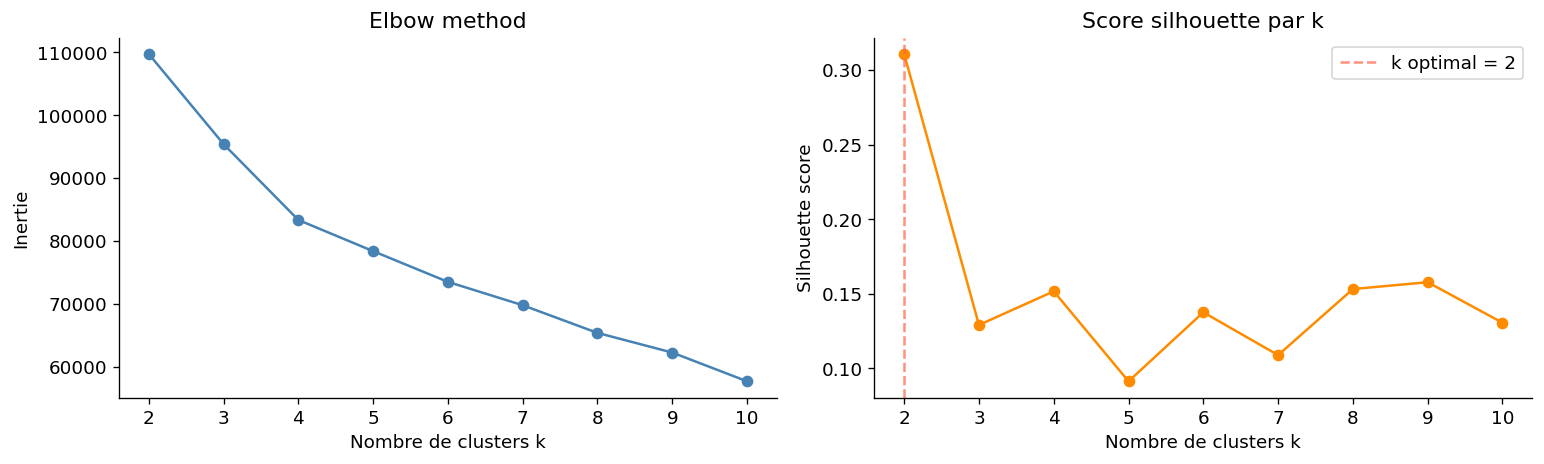


k optimal (silhouette) : 2


In [85]:
# ── 8.1 Elbow method ─────────────────────────────────────────────────────
X_cluster = PCA(n_components=min(20, X_scaled.shape[1], X_scaled.shape[0]-1),
                random_state=RANDOM_STATE).fit_transform(X_scaled)

k_range = range(2, min(11, X.shape[0]))
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_cluster, labels_k) if k > 1 else 0
    silhouettes.append(sil)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(k_range), inertias, 'o-', color='steelblue')
axes[0].set_xlabel('Nombre de clusters k')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Elbow method')

axes[1].plot(list(k_range), silhouettes, 'o-', color='darkorange')
best_k = list(k_range)[np.argmax(silhouettes)]
axes[1].axvline(best_k, color='tomato', linestyle='--', alpha=0.7, label=f'k optimal = {best_k}')
axes[1].set_xlabel('Nombre de clusters k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Score silhouette par k')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '12_kmeans_elbow.png'), bbox_inches='tight')
plt.show()
print(f"\nk optimal (silhouette) : {best_k}")

KMeans k=2 vs labels réels :
  Adjusted Rand Index (ARI)         : 0.1757  (1=parfait, 0=aléatoire)
  Normalized Mutual Information NMI : 0.0665
  Silhouette score clusters         : 0.3107


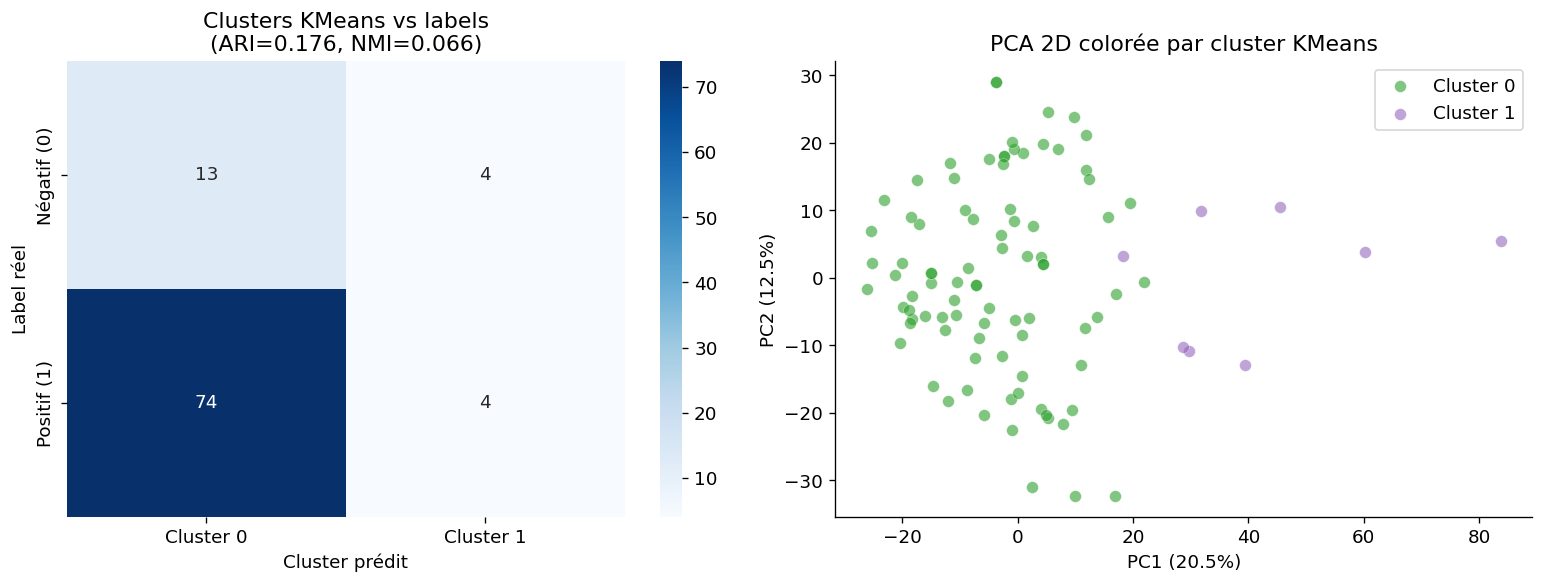

In [86]:
# ── 8.2 KMeans k=2 vs labels réels ───────────────────────────────────────
km2 = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
clusters = km2.fit_predict(X_cluster)

ari  = adjusted_rand_score(y, clusters)
nmi  = normalized_mutual_info_score(y, clusters)
sil2 = silhouette_score(X_cluster, clusters)

print(f"KMeans k=2 vs labels réels :")
print(f"  Adjusted Rand Index (ARI)         : {ari:.4f}  (1=parfait, 0=aléatoire)")
print(f"  Normalized Mutual Information NMI : {nmi:.4f}")
print(f"  Silhouette score clusters         : {sil2:.4f}")

# Confusion matrix clusters vs labels
cm = confusion_matrix(y, clusters)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cluster 0', 'Cluster 1'],
            yticklabels=list(LABEL_NAMES.values()), ax=axes[0])
axes[0].set_title(f'Clusters KMeans vs labels\n(ARI={ari:.3f}, NMI={nmi:.3f})')
axes[0].set_xlabel('Cluster prédit')
axes[0].set_ylabel('Label réel')

# Projection PCA 2D colorée par cluster
cluster_colors = ['#2ca02c', '#9467bd']
for c_val in [0, 1]:
    mask = clusters == c_val
    axes[1].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    c=cluster_colors[c_val], label=f'Cluster {c_val}',
                    alpha=0.6, s=50, edgecolors='white', linewidths=0.3)
axes[1].set_title('PCA 2D colorée par cluster KMeans')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '13_kmeans_analysis.png'), bbox_inches='tight')
plt.show()

## 9. Récapitulatif

In [87]:
print("=" * 60)
print("  RÉCAPITULATIF — Analyse de l'espace latent")
print("=" * 60)
print(f"  Dataset          : {X.shape[0]} WSI | dim={X.shape[1]}")
print(f"  Labels           : 0={( y==0).sum()} | 1={(y==1).sum()}")
print("─" * 60)
print(f"  Variance PCA :")
print(f"    90% de variance expliquée en {n_90} composantes")
print(f"    95% de variance expliquée en {n_95} composantes")
print(f"    99% de variance expliquée en {n_99} composantes")
print("─" * 60)
print("  Silhouette scores :")
for name, score in sil_scores.items():
    print(f"    {name:>22s} : {score:.4f}")
print("─" * 60)
print(f"  KMeans k=2 vs labels :")
print(f"    ARI = {ari:.4f} | NMI = {nmi:.4f}")
print("─" * 60)
print(f"  Figures sauvegardées dans : {os.path.abspath(OUTPUT_DIR)}")
print("=" * 60)

# Interprétation automatique
sil_pca2 = sil_scores.get('PCA 2D', 0)
if sil_pca2 > 0.3:
    print("\n✅ Bonne séparabilité linéaire (PCA) — les deux classes forment des clusters distincts.")
elif sil_pca2 > 0.1:
    print("\n⚠️  Séparabilité modérée — les classes se chevauchent partiellement en PCA.")
else:
    print("\n❌ Faible séparabilité linéaire — vérifier UMAP/t-SNE pour des structures non-linéaires.")

if ari > 0.5:
    print("✅ Fort alignement clustering non supervisé / labels — structure bien capturée.")
elif ari > 0.2:
    print("⚠️  Alignement partiel clustering / labels.")
else:
    print("❌ Faible alignement clustering / labels — les embeddings ne séparent pas clairement les deux classes.")

  RÉCAPITULATIF — Analyse de l'espace latent
  Dataset          : 95 WSI | dim=1536
  Labels           : 0=17 | 1=78
────────────────────────────────────────────────────────────
  Variance PCA :
    90% de variance expliquée en 24 composantes
    95% de variance expliquée en 36 composantes
    99% de variance expliquée en 64 composantes
────────────────────────────────────────────────────────────
  Silhouette scores :
          Brut (normalisé) : 0.1129
               PCA (50 PC) : 0.1169
                    PCA 2D : 0.2104
                  t-SNE 2D : 0.1013
                   UMAP 2D : 0.0710
────────────────────────────────────────────────────────────
  KMeans k=2 vs labels :
    ARI = 0.1757 | NMI = 0.0665
────────────────────────────────────────────────────────────
  Figures sauvegardées dans : c:\Users\manon\Documents\pathology_MIL\notebooks\figures

⚠️  Séparabilité modérée — les classes se chevauchent partiellement en PCA.
❌ Faible alignement clustering / labels — les embedding